In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/content/drive/MyDrive/div2k'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0001.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0002.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0003.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0004.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0005.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0006.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0007.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0008.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0009.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0010.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0011.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0012.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0013.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0014.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0015.png
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0016.png
/content/drive/MyDrive/d

In [4]:
!pip install -q super-image

import os
from glob import glob
import re
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from super_image import MsrnModel
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.9/95.9 kB 3.0 MB/s eta 0:00:00


In [5]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SCALE = 4

BASE_DIR = '/content/drive/MyDrive/div2k/Dataset'

HR_TRAIN_DIR = os.path.join(BASE_DIR, 'DIV2K_train_HR')
LR_TRAIN_DIR = os.path.join(BASE_DIR, 'DIV2K_train_LR_bicubic_X4', 'X4')

print(HR_TRAIN_DIR)
print(LR_TRAIN_DIR)

print('HR train count:', len(glob(os.path.join(HR_TRAIN_DIR, "*.png"))))
print('LR train count:', len(glob(os.path.join(LR_TRAIN_DIR, "*.png"))))

def get_index(name: str):

    m = re.search(r'(\d{4})', name)
    return m.group(1) if m else None

def get_pairs_by_index(hr_dir, lr_dir, max_pairs=None):
    hr_files = sorted(glob(os.path.join(hr_dir, '*.png')))
    lr_files = sorted(glob(os.path.join(lr_dir, '*.png')))

    lr_map = {}
    for p in lr_files:
        idx = get_index(os.path.basename(p))
        if idx is not None:
            lr_map[idx] = p

    pairs = []
    for hr in hr_files:
        idx = get_index(os.path.basename(hr))
        if idx is not None and idx in lr_map:
            pairs.append((lr_map[idx], hr))
            if max_pairs is not None and len(pairs) >= max_pairs:
                break
    return pairs

pairs = get_pairs_by_index(HR_TRAIN_DIR, LR_TRAIN_DIR)
print('Total LR/HR pairs for evaluation', len(pairs))
print(pairs[:3])

/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR
/content/drive/MyDrive/div2k/Dataset/DIV2K_train_LR_bicubic_X4/X4
HR train count: 800
LR train count: 800
Total LR/HR pairs for evaluation 800
[('/content/drive/MyDrive/div2k/Dataset/DIV2K_train_LR_bicubic_X4/X4/0001x4.png', '/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0001.png'), ('/content/drive/MyDrive/div2k/Dataset/DIV2K_train_LR_bicubic_X4/X4/0002x4.png', '/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0002.png'), ('/content/drive/MyDrive/div2k/Dataset/DIV2K_train_LR_bicubic_X4/X4/0003x4.png', '/content/drive/MyDrive/div2k/Dataset/DIV2K_train_HR/0003.png')]


In [6]:
class Div2KDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        lr_path, hr_path = self.pairs[idx]
        lr = Image.open(lr_path).convert('RGB')
        hr = Image.open(hr_path).convert('RGB')

        lr_np = np.array(lr).astype(np.float32) / 255.0
        hr_np = np.array(hr).astype(np.float32) / 255.0

        lr_tensor = torch.from_numpy(lr_np).permute(2, 0, 1)
        hr_tensor = torch.from_numpy(hr_np).permute(2, 0, 1)
        return lr_tensor, hr_tensor

val_dataset = Div2KDataset(pairs)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=2)

**MR-SDE**

In [15]:
# The MRSDE class definition has been moved to cell 7I3bObbh4Gr3

**Activation-Free Fourier Block (AFFB)**

In [9]:
# models/affb.py
import torch
import torch.nn as nn
import torch.fft

class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class SFFB(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.freq_conv = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        fft = torch.fft.fft2(x, norm="ortho")
        fft = self.freq_conv(fft.real).type(torch.complex64)
        out = torch.fft.ifft2(fft, norm="ortho").real
        return out + x

class AFFB(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm([channels, 1, 1])
        self.dwconv = nn.Conv2d(channels, channels, 3, padding=1, groups=channels)
        self.sffb = SFFB(channels)
        self.conv = nn.Conv2d(channels, channels * 2, 1)
        self.gate = SimpleGate()
        self.alpha = nn.Parameter(torch.zeros(1))
        self.beta = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        y = self.norm(x)
        y = self.dwconv(y)
        y = self.sffb(y)
        y = self.conv(y)
        y = self.gate(y)
        return x + self.alpha * y


**LR Encoder (RRDB-based)**

In [10]:
# models/lr_encoder.py
import torch
import torch.nn as nn

class RRDBBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(channels, channels, 3, 1, 1)
        )

    def forward(self, x):
        return x + self.block(x)

class LREncoder(nn.Module):
    def __init__(self, channels=64, num_blocks=8):
        super().__init__()
        self.conv = nn.Conv2d(3, channels, 3, 1, 1)
        self.blocks = nn.Sequential(*[RRDBBlock(channels) for _ in range(num_blocks)])

    def forward(self, x):
        x = self.conv(x)
        return self.blocks(x)


**Conditional Noise Predictor (U-Net + AFFB)**

In [12]:
# models/noise_predictor.py
import torch
import torch.nn as nn
import torch.fft # Added this import

# Definitions copied from models/affb.py
class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class SFFB(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.freq_conv = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        fft = torch.fft.fft2(x, norm="ortho")
        fft = self.freq_conv(fft.real).type(torch.complex64)
        out = torch.fft.ifft2(fft, norm="ortho").real
        return out + x

class AFFB(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm([channels, 1, 1])
        self.dwconv = nn.Conv2d(channels, channels, 3, padding=1, groups=channels)
        self.sffb = SFFB(channels)
        self.conv = nn.Conv2d(channels, channels * 2, 1)
        self.gate = SimpleGate()
        self.alpha = nn.Parameter(torch.zeros(1))
        self.beta = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        y = self.norm(x)
        y = self.dwconv(y)
        y = self.sffb(y)
        y = self.conv(y)
        y = self.gate(y)
        return x + self.alpha * y
# End of copied definitions

class NoisePredictor(nn.Module):
    def __init__(self, base_ch=64):
        super().__init__()
        self.in_conv = nn.Conv2d(3, base_ch, 3, 1, 1)

        self.enc1 = AFFB(base_ch)
        self.enc2 = AFFB(base_ch * 2)

        self.down = nn.Conv2d(base_ch, base_ch * 2, 4, 2, 1)
        self.up = nn.ConvTranspose2d(base_ch * 2, base_ch, 4, 2, 1)

        self.dec1 = AFFB(base_ch)
        self.out_conv = nn.Conv2d(base_ch, 3, 3, 1, 1)

    def forward(self, x, lr_feat):
        x = self.in_conv(x)
        e1 = self.enc1(x + lr_feat)
        e2 = self.enc2(self.down(e1))
        d1 = self.up(e2) + e1
        d1 = self.dec1(d1)
        return self.out_conv(d1)


In [7]:
model = MsrnModel.from_pretrained('eugenesiow/msrn', scale=SCALE).to(DEVICE)
model.eval()  # только инференс, без обучения

def tensor_to_np(img_tensor):
    img = img_tensor.detach().cpu().numpy()
    img = np.clip(img, 0.0, 1.0)
    img = np.transpose(img, (1, 2, 0))  # (C,H,W) -> (H,W,C)
    return img

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/145 [00:00<?, ?B/s]

pytorch_model_4x.pt:   0%|          | 0.00/24.3M [00:00<?, ?B/s]

https://huggingface.co/eugenesiow/msrn/resolve/main/pytorch_model_4x.pt


In [14]:
# training/train.py
import torch
import math

# MRSDE class definition moved from YzftHFrd3YsZ
class MRSDE:
    def __init__(self, theta=1.0, sigma=1.0):
        self.theta = theta
        self.sigma = sigma

    def marginal_prob(self, x0, mu, t):
        alpha = torch.exp(-self.theta * t)
        mean = alpha * x0 + (1 - alpha) * mu
        var = (self.sigma ** 2 / (2 * self.theta)) * (1 - alpha ** 2)
        return mean, var

    def forward_diffusion(self, x0, mu, t):
        mean, var = self.marginal_prob(x0, mu, t)
        noise = torch.randn_like(x0)
        xt = mean + torch.sqrt(var) * noise
        return xt, noise

def train(model, lr_encoder, dataloader, optimizer, device):
    sde = MRSDE()
    model.train()

    for lr, hr in dataloader:
        lr, hr = lr.to(device), hr.to(device)

        mu = torch.nn.functional.interpolate(lr, scale_factor=4, mode='bicubic')
        lr_feat = lr_encoder(lr)

        t = torch.rand(lr.size(0), device=device)
        xt, noise = sde.forward_diffusion(hr, mu, t)

        pred_noise = model(xt, lr_feat)
        loss = torch.mean((pred_noise - noise) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


In [16]:
@torch.no_grad()
def sample(lr, noise_net, lr_encoder, mrsde):
    mu = torch.nn.functional.interpolate(lr, scale_factor=4, mode='bicubic')
    x = mu + torch.randn_like(mu)

    lr_feat = lr_encoder(lr)

    for t in reversed(range(mrsde.T)):
        noise = noise_net(x, lr_feat)
        x = x - noise

    return x


In [17]:
def color_correction(sr, lr):
    for c in range(3):
        sr[:, c] = (
            (sr[:, c] - sr[:, c].mean()) / sr[:, c].std()
        ) * lr[:, c].std() + lr[:, c].mean()
    return sr


In [8]:
psnr_list_msrn, ssim_list_msrn = [], []
psnr_list_bicubic, ssim_list_bicubic = [], []

with torch.no_grad():
    for lr_tensor, hr_tensor in tqdm(val_loader):
        lr_tensor = lr_tensor.to(DEVICE)
        hr_tensor = hr_tensor.to(DEVICE)

        sr_tensor = model(lr_tensor)

        sr_np = tensor_to_np(sr_tensor[0])
        hr_np = tensor_to_np(hr_tensor[0])

        lr_np = tensor_to_np(lr_tensor[0])
        lr_img = Image.fromarray((lr_np * 255).astype(np.uint8))
        bicubic_img = lr_img.resize((hr_np.shape[1], hr_np.shape[0]), Image.BICUBIC)
        bicubic_np = np.array(bicubic_img).astype(np.float32) / 255.0

        psnr_m = psnr_metric(hr_np, sr_np, data_range=1.0)
        psnr_b = psnr_metric(hr_np, bicubic_np, data_range=1.0)

        ssim_m = ssim_metric(
            hr_np, sr_np,
            data_range=1.0,
            channel_axis=-1,
            win_size=7
        )
        ssim_b = ssim_metric(
            hr_np, bicubic_np,
            data_range=1.0,
            channel_axis=-1,
            win_size=7
        )

        psnr_list_msrn.append(psnr_m)
        ssim_list_msrn.append(ssim_m)
        psnr_list_bicubic.append(psnr_b)
        ssim_list_bicubic.append(ssim_b)

print('MSRN x4:  PSNR =', float(np.mean(psnr_list_msrn)), ' SSIM =', float(np.mean(ssim_list_msrn)))
print('Bicubic:  PSNR =', float(np.mean(psnr_list_bicubic)), ' SSIM =', float(np.mean(ssim_list_bicubic)))

100%|██████████| 800/800 [7:45:45<00:00, 34.93s/it]

MSRN x4:  PSNR = 28.93759830217641  SSIM = 0.8407012224197388
Bicubic:  PSNR = 26.64686298412481  SSIM = 0.7727963328361511


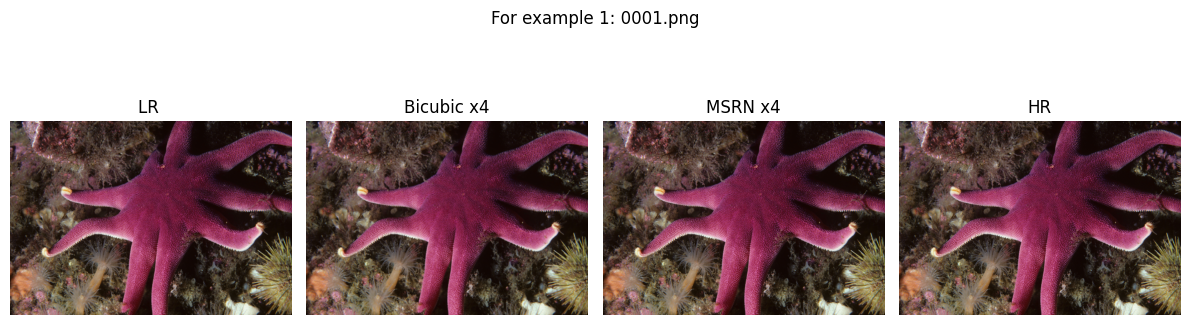

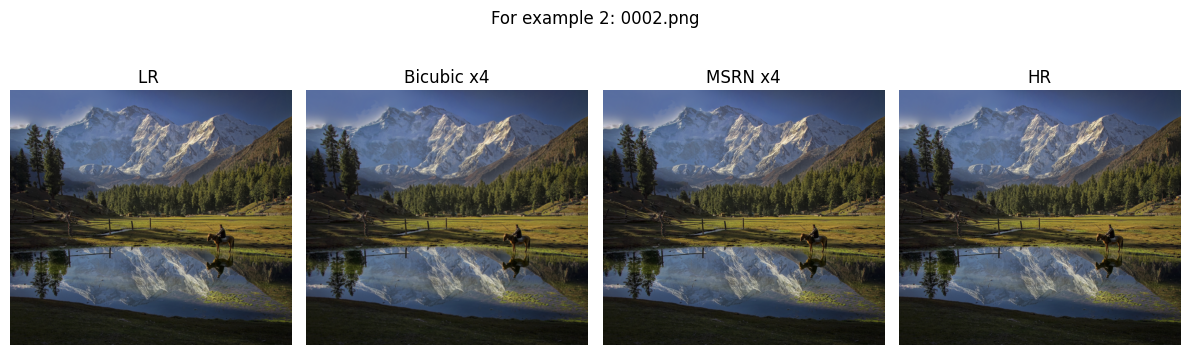

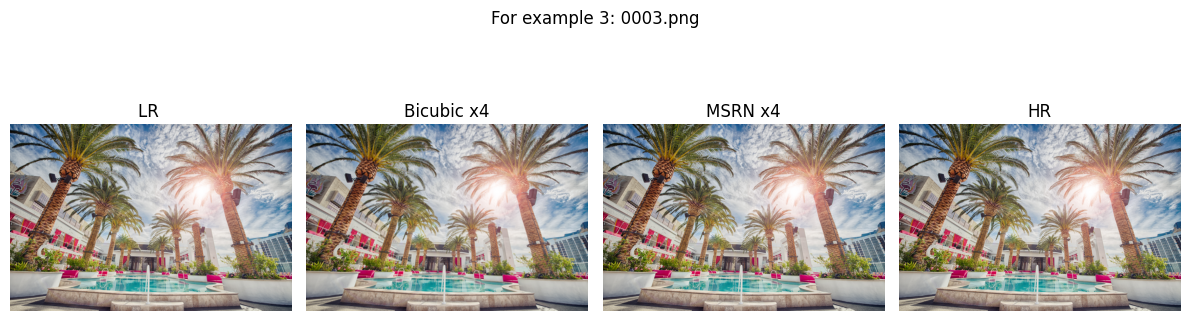

In [9]:
import matplotlib.pyplot as plt

num_examples = 3

for i in range(num_examples):
    lr_path, hr_path = pairs[i]

    lr = Image.open(lr_path).convert('RGB')
    hr = Image.open(hr_path).convert('RGB')

    lr_np = np.array(lr).astype(np.float32) / 255.0
    hr_np = np.array(hr).astype(np.float32) / 255.0

    lr_tensor = torch.from_numpy(lr_np).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        sr_tensor = model(lr_tensor)

    sr_np = sr_tensor[0].detach().cpu().numpy()
    sr_np = np.clip(sr_np, 0.0, 1.0)
    sr_np = np.transpose(sr_np, (1, 2, 0))

    lr_img = Image.fromarray((lr_np * 255).astype(np.uint8))
    bicubic_img = lr_img.resize((hr_np.shape[1], hr_np.shape[0]), Image.BICUBIC)
    bicubic_np = np.array(bicubic_img).astype(np.float32) / 255.0

    plt.figure(figsize=(12, 4))
    plt.suptitle(f'For example {i+1}: {os.path.basename(hr_path)}')

    plt.subplot(1, 4, 1)
    plt.imshow(lr_np)
    plt.title('LR ')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(bicubic_np)
    plt.title('Bicubic x4')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(sr_np)
    plt.title('MSRN x4')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(hr_np)
    plt.title('HR')
    plt.axis('off')

    plt.tight_layout()
    plt.show()